# Fitting a Generalised Additive model with smooth function

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cs2_newestcombinedmatches.csv")

df.head()

,match_id,hltv_match_id,date,tournament,winner,season,score_team1,score_team2,winner_map,loser_map,...,star_player_advantage,team1_weakest_player,team2_weakest_player,weakest_link_advantage,team1_online_winrate,team2_online_winrate,team1_lan_winrate,team2_lan_winrate,team1_overall_winrate,team2_overall_winrate
0,hltv_match_2371997,2371997,2024-05-15T06:00:00Z,BetBoom Dacha Belgrade 2024,team1,8,2,0,Ancient,Dust2,...,0.15,0.94,0.93,0.01,0.000000,0.442308,0.460317,0.379310,0.5,0.5
1,hltv_match_2372188,2372188,2024-05-15T08:00:00Z,RES Regional Series 4 Europe,team2,8,1,2,Nuke,Anubis,...,0.03,0.98,0.91,0.07,0.410714,0.398058,0.478261,0.285714,0.5,0.5
2,hltv_match_2372226,2372226,2024-05-15T08:30:00Z,CCT Season 2 Europe Series 4 Closed Qualifier,team2,8,1,2,Ancient,Vertigo,...,0.03,0.82,0.98,-0.16,0.500000,0.506173,0.500000,0.000000,0.5,0.5
3,hltv_match_2371998,2371998,2024-05-15T08:45:00Z,BetBoom Dacha Belgrade 2024,team1,8,2,1,Dust2,Anubis,...,-0.15,0.99,1.09,-0.10,0.333333,0.408163,0.590164,0.500000,0.5,0.5
4,hltv_match_2372273,2372273,2024-05-15T09:30:00Z,ESL Challenger League Season 47 Europe,team1,8,2,0,Ancient,Vertigo,...,-0.04,0.99,0.96,0.03,0.555556,0.626374,1.000000,0.545455,0.5,0.5


In [3]:
cols = [
    "winner",
    "team1_avg_RATING",
    "team1_player_1_RATING",
    "team1_player_2_RATING",
    "team1_player_3_RATING",
    "team1_player_4_RATING",
    "team1_player_5_RATING",
    "team2_avg_RATING",
    "team2_player_1_RATING",
    "team2_player_2_RATING",
    "team2_player_3_RATING",
    "team2_player_4_RATING",
    "team2_player_5_RATING",
]

df = df[cols]
df.head()

,winner,team1_avg_RATING,team1_player_1_RATING,team1_player_2_RATING,team1_player_3_RATING,team1_player_4_RATING,team1_player_5_RATING,team2_avg_RATING,team2_player_1_RATING,team2_player_2_RATING,team2_player_3_RATING,team2_player_4_RATING,team2_player_5_RATING
0,team1,1.14,0.94,1.26,1.12,1.31,1.09,1.07,0.93,1.16,1.11,1.09,1.08
1,team2,1.05,0.98,1.12,1.09,1.03,1.01,1.02,0.91,1.00,1.07,1.03,1.09
2,team2,0.99,0.98,0.82,1.02,1.04,1.10,1.04,1.02,1.06,1.05,0.98,1.07
3,team1,1.06,1.07,0.99,1.13,1.01,1.08,1.15,1.11,1.09,1.09,1.17,1.28
4,team1,1.03,1.04,1.08,0.99,1.05,1.01,1.06,0.96,1.12,1.06,1.09,1.06


In [4]:
dft1p1 = df[["winner", "team1_player_1_RATING"]]


def label_winner(row):
    if row["winner"] == "team1":
        return 1
    return 0


dft1p1["winner"] = dft1p1.apply(label_winner, axis=1)
dft1p1 = dft1p1.rename(columns={"winner": "won", "team1_player_1_RATING": "rating"})

dft1p1.head()

,won,rating
0,1,0.94
1,0,0.98
2,0,0.98
3,1,1.07
4,1,1.04


In [5]:
dft1p2 = df[["winner", "team1_player_2_RATING"]]
dft1p2["winner"] = dft1p2.apply(label_winner, axis=1)
dft1p2 = dft1p2.rename(columns={"winner": "won", "team1_player_2_RATING": "rating"})

dft1p3 = df[["winner", "team1_player_3_RATING"]]
dft1p3["winner"] = dft1p3.apply(label_winner, axis=1)
dft1p3 = dft1p3.rename(columns={"winner": "won", "team1_player_3_RATING": "rating"})

dft1p4 = df[["winner", "team1_player_4_RATING"]]
dft1p4["winner"] = dft1p4.apply(label_winner, axis=1)
dft1p4 = dft1p4.rename(columns={"winner": "won", "team1_player_4_RATING": "rating"})

dft1p5 = df[["winner", "team1_player_5_RATING"]]
dft1p5["winner"] = dft1p5.apply(label_winner, axis=1)
dft1p5 = dft1p5.rename(columns={"winner": "won", "team1_player_5_RATING": "rating"})

In [6]:
def label_winner(row):
    if row["winner"] == "team1":
        return 0
    return 1


dft2p1 = df[["winner", "team2_player_1_RATING"]]
dft2p1["winner"] = dft2p1.apply(label_winner, axis=1)
dft2p1 = dft2p1.rename(columns={"winner": "won", "team2_player_1_RATING": "rating"})

dft2p2 = df[["winner", "team2_player_2_RATING"]]
dft2p2["winner"] = dft2p2.apply(label_winner, axis=1)
dft2p2 = dft2p2.rename(columns={"winner": "won", "team2_player_2_RATING": "rating"})

dft2p3 = df[["winner", "team2_player_3_RATING"]]
dft2p3["winner"] = dft2p3.apply(label_winner, axis=1)
dft2p3 = dft2p3.rename(columns={"winner": "won", "team2_player_3_RATING": "rating"})

dft2p4 = df[["winner", "team2_player_4_RATING"]]
dft2p4["winner"] = dft2p4.apply(label_winner, axis=1)
dft2p4 = dft2p4.rename(columns={"winner": "won", "team2_player_4_RATING": "rating"})

dft2p5 = df[["winner", "team2_player_5_RATING"]]
dft2p5["winner"] = dft2p5.apply(label_winner, axis=1)
dft2p5 = dft2p5.rename(columns={"winner": "won", "team2_player_5_RATING": "rating"})

In [7]:
final_df = pd.concat(
    [dft1p1, dft1p2, dft1p3, dft1p4, dft1p5, dft2p1, dft2p2, dft2p3, dft2p4, dft2p5],
    ignore_index=True,
)

final_df.head()

,won,rating
0,1,0.94
1,0,0.98
2,0,0.98
3,1,1.07
4,1,1.04


In [8]:
final_df.describe()

,won,rating
count,70330.000000,68132.000000
mean,0.500000,1.061917
std,0.500004,0.074044
min,0.000000,0.590000
25%,0.000000,1.020000
50%,0.500000,1.070000
75%,1.000000,1.110000
max,1.000000,1.700000


In [9]:
final_df = final_df.dropna()

final_df.describe()

,won,rating
count,68132.000000,68132.000000
mean,0.501629,1.061917
std,0.500001,0.074044
min,0.000000,0.590000
25%,0.000000,1.020000
50%,1.000000,1.070000
75%,1.000000,1.110000
max,1.000000,1.700000


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pygam import LogisticGAM, s

In [11]:
x = final_df["rating"]
y = final_df["won"]

x.describe()

count    68132.000000
mean         1.061917
std          0.074044
min          0.590000
25%          1.020000
50%          1.070000
75%          1.110000
max          1.700000
Name: rating, dtype: float64

In [12]:
x = final_df["rating"]
y = final_df["won"]

gam = LogisticGAM(
    s(0, n_splines=30, spline_order=3, constraints="monotonic_inc"),
    max_iter=200,
    tol=1e-4,
)

gam.fit(x, y)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=200, terms=s(0) + intercept, 
   tol=0.0001, verbose=False)

In [13]:
for r in [0.5, 0.7, 0.85, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5, 1.8]:
    p = gam.predict_proba([[r]])[0]
    print(f"{r:.2f}: {p:.3f}")
for r in [0.5, 0.7, 0.85, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5, 1.8]:
    p = gam.predict_proba([[r]])[0]
    print(f"{r:.2f}: {p:.3f}")

0.50: 0.048
0.70: 0.129
0.85: 0.317
1.00: 0.457
1.05: 0.502
1.10: 0.530
1.20: 0.561
1.30: 0.662
1.50: 0.872
1.80: 0.991
0.50: 0.048
0.70: 0.129
0.85: 0.317
1.00: 0.457
1.05: 0.502
1.10: 0.530
1.20: 0.561
1.30: 0.662
1.50: 0.872
1.80: 0.991


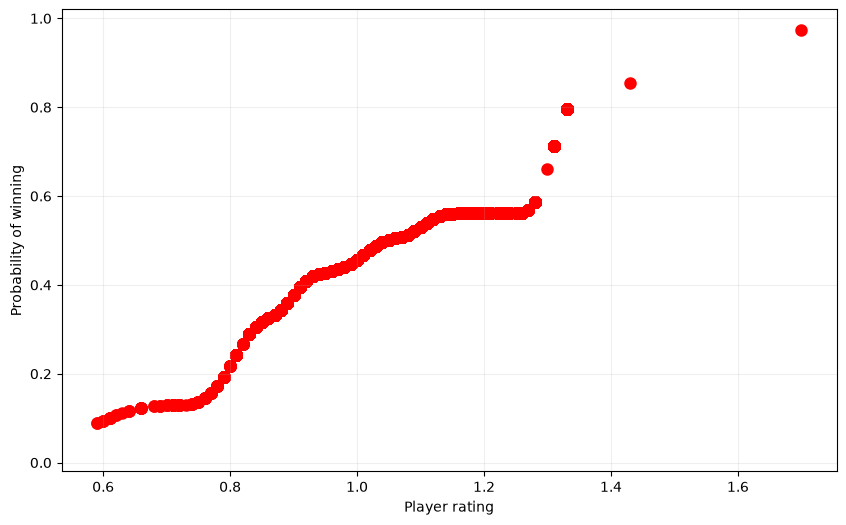

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(x, gam.predict_proba(x), color="red", linewidth=3)

plt.xlabel("Player rating")
plt.ylabel("Probability of winning")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.2)

plt.show()

In [15]:
summary = final_df.groupby("rating")["won"].agg(["mean", "count"]).reset_index()

summary.head()

,rating,mean,count
0,0.59,0.000000,2
1,0.60,0.333333,3
2,0.61,0.000000,7
3,0.62,0.000000,2
4,0.63,0.000000,1


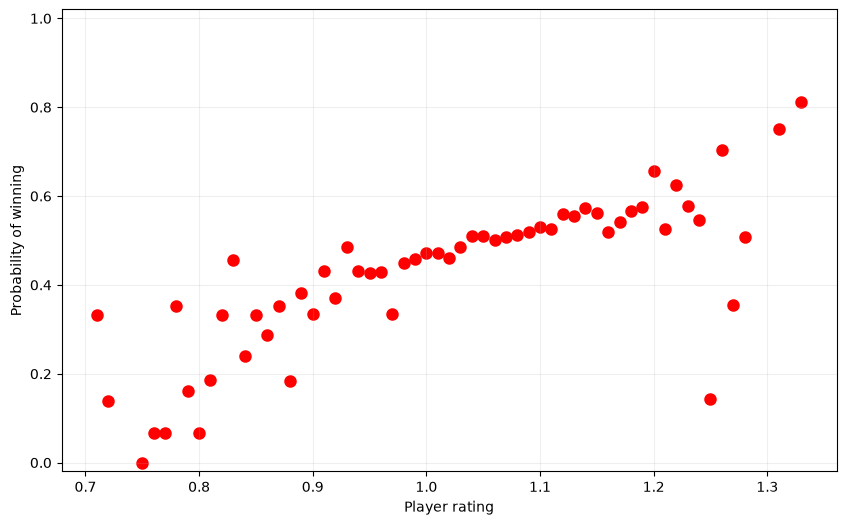

In [16]:
plt.figure(figsize=(10, 6))

summary = summary[summary["count"] > 10]

plt.scatter(summary["rating"], summary["mean"], color="red", linewidth=3)

plt.xlabel("Player rating")
plt.ylabel("Probability of winning")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.2)

plt.show()

## Trying various configurations

In [17]:
x = final_df["rating"]
y = final_df["won"]

gam = LogisticGAM(
    s(
        0,
        spline_order=3,
        constraints="monotonic_inc",
    ),
    max_iter=500,
    tol=1e-4,
)

lam_grid = np.logspace(-3, 3, 40)
spline_grid = [20, 30, 50, 70, 90]

results = gam.gridsearch(x, y, lam=lam_grid, n_splines=spline_grid, return_scores=True)

100% (200 of 200) |######################| Elapsed Time: 0:17:34 Time:  0:17:341027


In [19]:
print(results)

OrderedDict({LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False): np.float64(3.374789431065282), LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False): np.float64(3.374400916250925), LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False): np.float64(3.3743374197425826), LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False): np.float64(3.3742256528885033), LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False): np.float64(3.374231852058751), LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=

In [ ]:
key = max(results.items(), key=lambda item: item[1])[0]
print(key)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False)


In [ ]:
value = results[key]
print(value)

3.375024784718001


In [31]:
key.get_params()

{'max_iter': 500,
 'tol': 0.0001,
 'callbacks': [Deviance(), Diffs(), Accuracy()],
 'verbose': False,
 'terms': s(0) + intercept,
 'fit_intercept': True}

In [32]:
key.lam

[[np.float64(1000.0)]]

In [34]:
key.n_splines

[20]

In [35]:
opt_gam = LogisticGAM(
    s(0, spline_order=3, constraints="monotonic_inc", lam=1000, n_splines=20),
    max_iter=500,
    tol=1e-4,
)

opt_gam.fit(x, y)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=500, terms=s(0) + intercept, 
   tol=0.0001, verbose=False)

In [36]:
for r in [0.5, 0.7, 0.85, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5, 1.8]:
    p = opt_gam.predict_proba([[r]])[0]
    print(f"{r:.2f}: {p:.3f}")

0.50: 0.082
0.70: 0.191
0.85: 0.324
1.00: 0.461
1.05: 0.499
1.10: 0.531
1.20: 0.583
1.30: 0.634
1.50: 0.736
1.80: 0.852


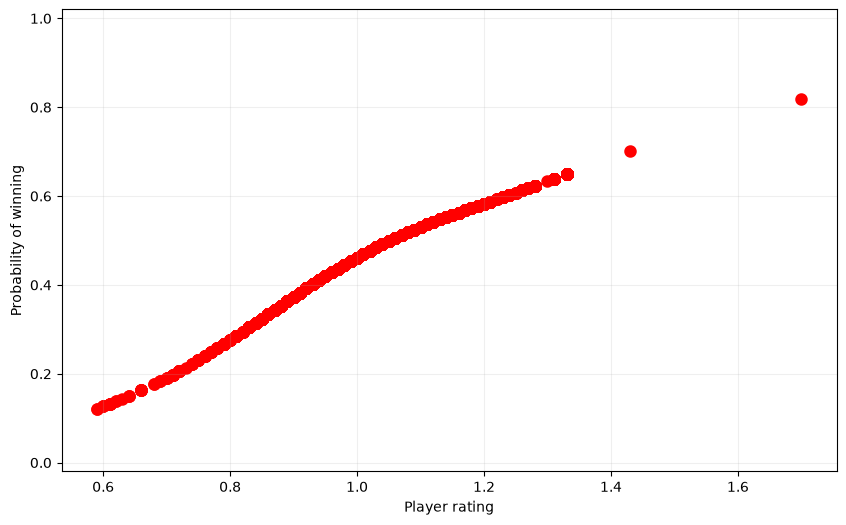

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(x, opt_gam.predict_proba(x), color="red", linewidth=3)

plt.xlabel("Player rating")
plt.ylabel("Probability of winning")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.2)

plt.show()

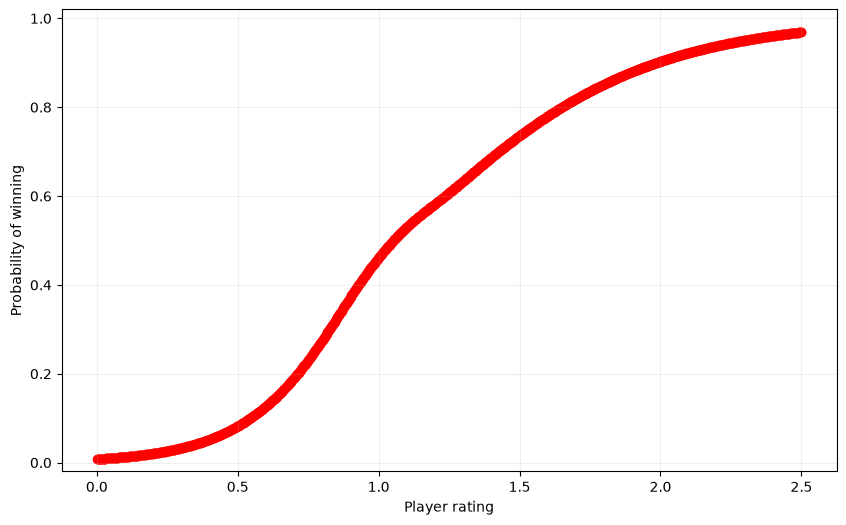

In [40]:
plt.figure(figsize=(10, 6))
x_plot = np.linspace(0, 2.5, 1000)

plt.scatter(x_plot, opt_gam.predict_proba(x_plot), color="red", linewidth=1)

plt.xlabel("Player rating")
plt.ylabel("Probability of winning")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.2)

plt.show()

In [39]:
import pathlib
import pickle

filename = "gam.pkl"

with pathlib.Path(filename).open("wb") as f:
    pickle.dump(opt_gam, f)

In [ ]:
# load with:
with pathlib.Path(filename).open("rb") as f:
    gam = pickle.load(f)